In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from grid_simulation import get_rgb_map
from cuda_square_simulation import SquareSimulation



In [39]:
def get_results_imgs(simulation, iterations=50, population_colors=None):

    pop1_size = []
    pop2_size = []
    pop3_size = []

    type1 = 'giving'
    type2 = 'attacking'
    type3 = 'complete'

    for i in range(iterations):
        action_grid = simulation.configurable_actions_grid(type1=type1, type2=type2, type3=type3)
        simulation.step(action_grid)

        pop1_size.append(simulation.grid[:,0].sum(dim=(1,2)).mean(dim=0))
        pop2_size.append(simulation.grid[:,1].sum(dim=(1,2)).mean(dim=0))
        pop3_size.append(simulation.grid[:,2].sum(dim=(1,2)).mean(dim=0))

    # Get the results
    #fig, ax = plt.subplots()
    #ax.set_aspect('equal')
    
    # Get the initial labels for batch 0.
    #rgb_map = get_rgb_map(simulation, ax)
    #im = ax.imshow(rgb_map)
    #ax.axis('off')

    plt.plot(np.arange(iterations), pop1_size, label=f'Population 1:{type1}', color='red')
    plt.plot(np.arange(iterations), pop2_size, label=f'Population 2:{type2}', color='blue')
    plt.plot(np.arange(iterations), pop3_size, label=f'Population 3:{type3}', color='green')
    plt.xlabel('Iterations')
    plt.ylabel('Population Size')
    plt.title('Population Size Over Time')
    plt.legend()
    plt.show()
    

    

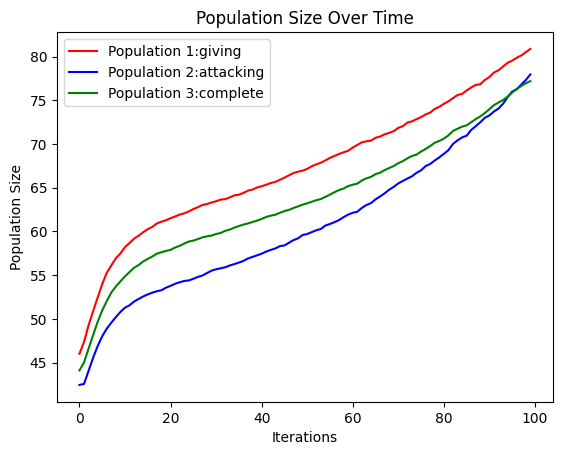

In [40]:
nb_batches = 100
rows, cols = 20, 20
populations = {
    "red": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "blue": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "green": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                populations=populations, device=device)
simulation.reset()

iterations = 100
get_results_imgs(simulation, iterations=iterations)